0.1999999999990898


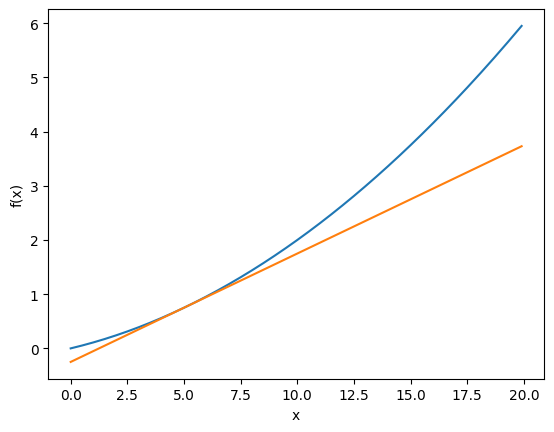

In [5]:
import numpy as np
import matplotlib.pylab as plt


def numerical_diff(f, x):
    h = 1e-4 # 0.0001
    return (f(x+h) - f(x-h)) / (2*h)


def function_1(x):
    return 0.01*x**2 + 0.1*x


def tangent_line(f, x):
    d = numerical_diff(f, x)
    print(d)
    y = f(x) - d*x
    return lambda t: d*t + y


def function_2(x):
  return x[0]^2 + x[1]^2


def function_3(x):
  return x[0]^2 - x[1]^2


x = np.arange(0.0, 20.0, 0.1)
y = function_1(x)
plt.xlabel("x")
plt.ylabel("f(x)")

tf = tangent_line(function_1, 5)
y2 = tf(x)

plt.plot(x, y)
plt.plot(x, y2)
plt.show()



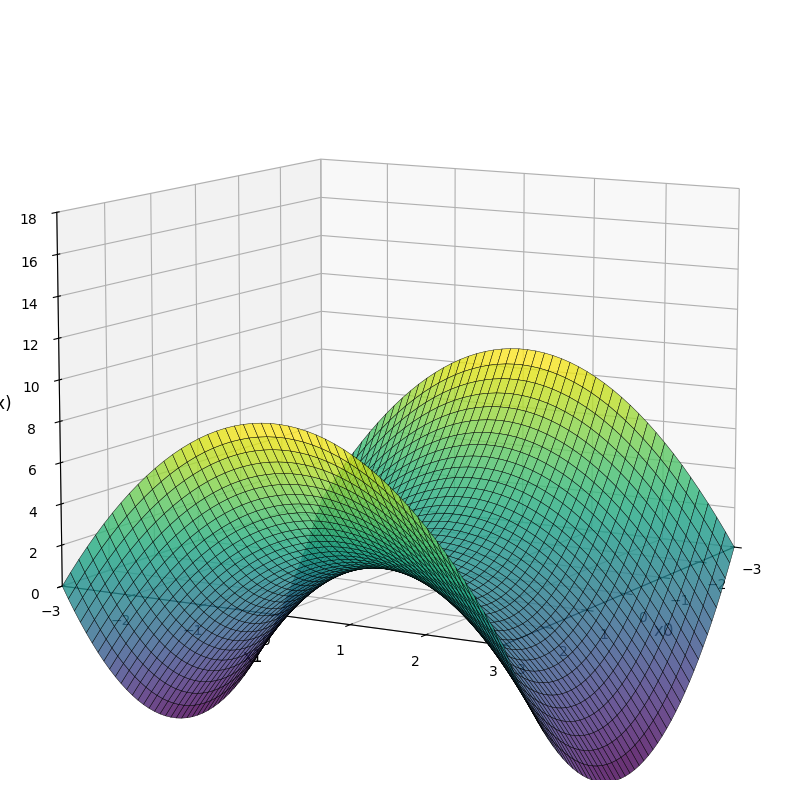

f([1.0, 2.0]) = -3.0


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def function_1(x):
    """
    ベクトル入力を受け取る2変数関数
    x[0]: 第1変数
    x[1]: 第2変数
    """
    return x[0]**2 + x[1]**2


def function_2(x):
    """
    ベクトル入力を受け取る2変数関数
    x[0]: 第1変数
    x[1]: 第2変数
    """
    return x[0]**2 - x[1]**2



# グリッドの生成
x0 = np.linspace(-3, 3, 50)
x1 = np.linspace(-3, 3, 50)
X0, X1 = np.meshgrid(x0, x1)

# 関数値の計算（ベクトル形式で入力）
s = int(input("関数を選んでください (0:放物線, 1:双曲放物線)"))
if s == 0:
  Z = function_1([X0, X1])
elif s == 1:
  Z = function_2([X0, X1])
else:
  Z = function_1([X0, X1])

# 3Dプロットの作成
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# サーフェスプロット
surf = ax.plot_surface(X0, X1, Z, cmap='viridis',
                       edgecolor='black', linewidth=0.3,
                       alpha=0.8, antialiased=True)

# 軸ラベルの設定
ax.set_xlabel('x0', fontsize=12)
ax.set_ylabel('x1', fontsize=12)
ax.set_zlabel('f(x)', fontsize=12)

# 視点の調整
ax.view_init(elev=10, azim=30)

# グリッドの表示
ax.grid(True)

# 軸の範囲設定
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_zlim(0, 18)

plt.tight_layout()
plt.show()

# 単一点での使用例
point = np.array([1.0, 2.0])
if s==0:
  result = function_1(point)
elif s==1:
  result = function_2(point)
print(f"f([1.0, 2.0]) = {result}")

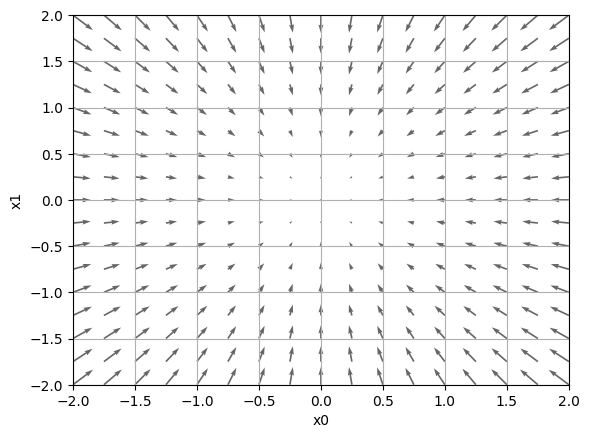

In [7]:
import numpy as np
import matplotlib.pylab as plt
from mpl_toolkits.mplot3d import Axes3D


def _numerical_gradient_no_batch(f, x):
    h = 1e-4  # 0.0001
    grad = np.zeros_like(x)

    for idx in range(x.size):
        tmp_val = x[idx]
        x[idx] = float(tmp_val) + h
        fxh1 = f(x)  # f(x+h)

        x[idx] = tmp_val - h
        fxh2 = f(x)  # f(x-h)
        grad[idx] = (fxh1 - fxh2) / (2*h)

        x[idx] = tmp_val  # 値を元に戻す

    return grad


def numerical_gradient(f, X):
    if X.ndim == 1:
        return _numerical_gradient_no_batch(f, X)
    else:
        grad = np.zeros_like(X)

        for idx, x in enumerate(X):
            grad[idx] = _numerical_gradient_no_batch(f, x)

        return grad


def function_2(x):
    if x.ndim == 1:
        return np.sum(x**2)
    else:
        return np.sum(x**2, axis=1)


def tangent_line(f, x):
    d = numerical_gradient(f, x)
    print(d)
    y = f(x) - d*x
    return lambda t: d*t + y


if __name__ == '__main__':
    x0 = np.arange(-2, 2.5, 0.25)
    x1 = np.arange(-2, 2.5, 0.25)
    X, Y = np.meshgrid(x0, x1)

    X = X.flatten()
    Y = Y.flatten()

    grad = numerical_gradient(function_2, np.array([X, Y]).T).T

    plt.figure()
    plt.quiver(X, Y, -grad[0], -grad[1],  angles="xy",color="#666666")
    plt.xlim([-2, 2])
    plt.ylim([-2, 2])
    plt.xlabel('x0')
    plt.ylabel('x1')
    plt.grid()
    plt.draw()
    plt.show()


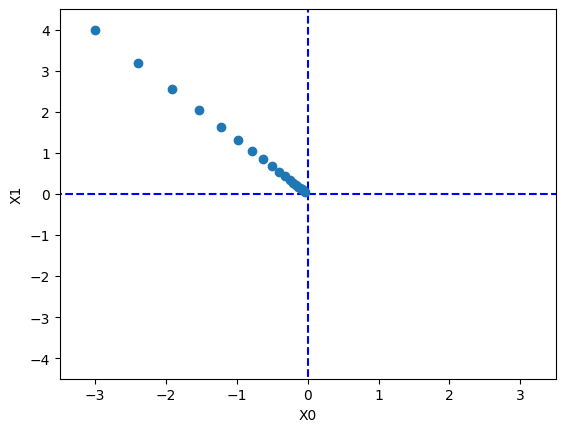

In [8]:
import numpy as np
import matplotlib.pylab as plt
from deep_learning_from_scratch_master.ch04.gradient_2d import numerical_gradient


def gradient_descent(f, init_x, lr=0.01, step_num=100):
    x = init_x
    x_history = []

    for i in range(step_num):
        x_history.append( x.copy() )

        grad = numerical_gradient(f, x)
        x -= lr * grad

    return x, np.array(x_history)


def function_2(x):
    return x[0]**2 + x[1]**2

init_x = np.array([-3.0, 4.0])

lr = 0.1
step_num = 20
x, x_history = gradient_descent(function_2, init_x, lr=lr, step_num=step_num)

plt.plot( [-5, 5], [0,0], '--b')
plt.plot( [0,0], [-5, 5], '--b')
plt.plot(x_history[:,0], x_history[:,1], 'o')

plt.xlim(-3.5, 3.5)
plt.ylim(-4.5, 4.5)
plt.xlabel("X0")
plt.ylabel("X1")
plt.show()
